<a href="https://colab.research.google.com/github/eayrault/Projet-Image/blob/main/projet_image_eliot_ayrault.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import torch
from transformers import YolosImageProcessor, YolosForObjectDetection, MaskFormerImageProcessor, MaskFormerForInstanceSegmentation
from PIL import Image, ImageDraw
import requests
import matplotlib.pyplot as plt
import numpy as np

# Installation des dépendances si nécessaire
# !pip install -q transformers torch torchvision pillow matplotlib

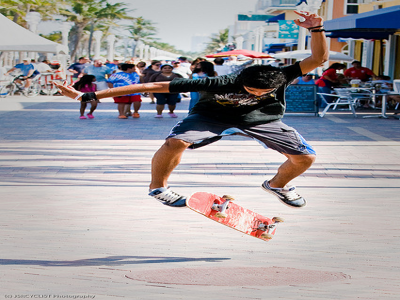

In [42]:
# 1. Récupération d'une image de test depuis MS COCO
url = "http://images.cocodataset.org/train2017/000000293802.jpg"
image = Image.open(requests.get(url, stream=True).raw)

display(image.resize((400, 300)))

In [43]:
# 2. Détection d'objets avec YOLOS
model_det_name = "hustvl/yolos-small"
processor_det = YolosImageProcessor.from_pretrained(model_det_name)
model_det = YolosForObjectDetection.from_pretrained(model_det_name)

inputs = processor_det(images=image, return_tensors="pt")
outputs = model_det(**inputs)

# Post-processing : on garde les détections avec un score > 0.9
target_sizes = torch.tensor([image.size[::-1]])
results = processor_det.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]

print(f"{len(results['scores'])} objets détectés.")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

15 objets détectés.


Loading weights:   0%|          | 0/648 [00:00<?, ?it/s]

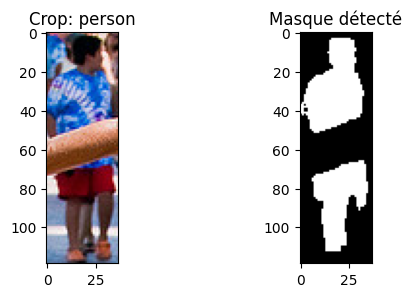

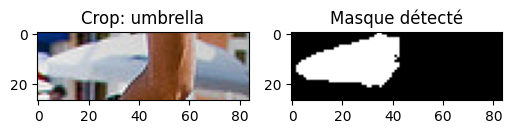

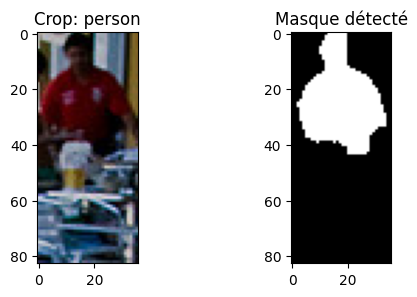

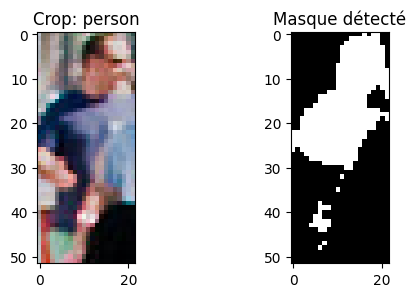

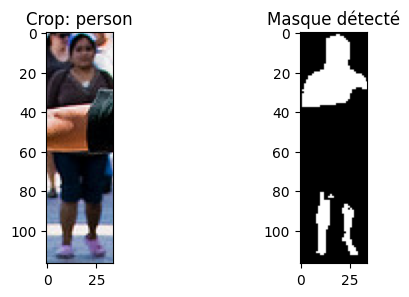

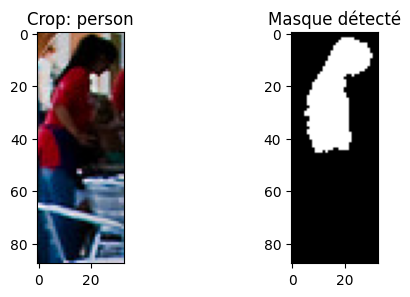

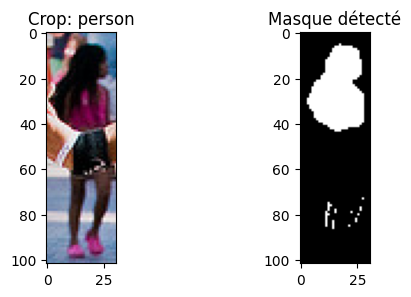

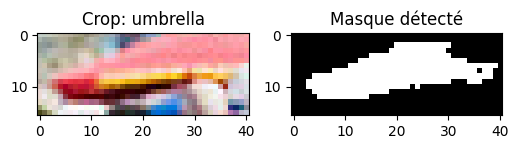

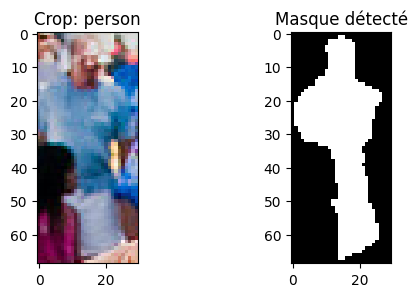

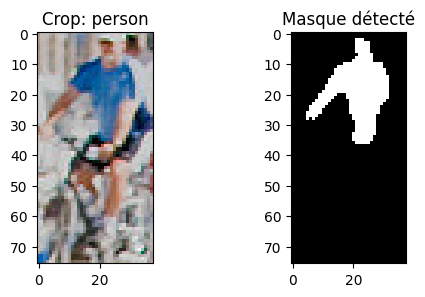

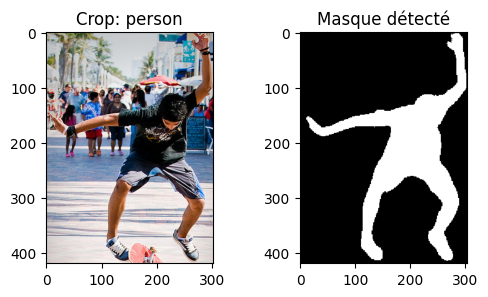

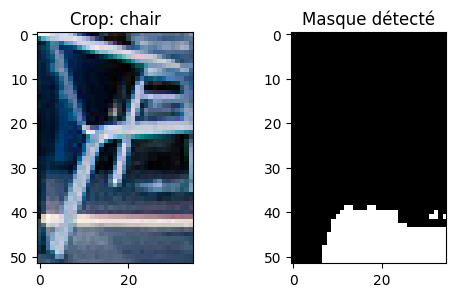

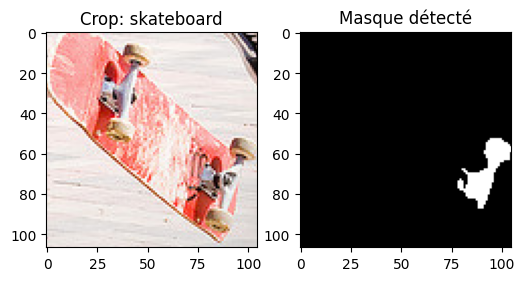

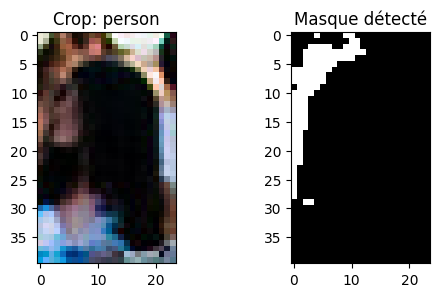

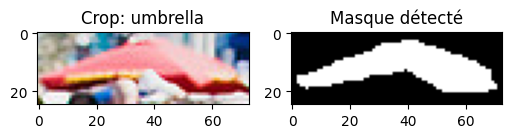

Segmentation terminée.


In [46]:
# 3. Pipeline d'extraction (crop) et segmentation (MaskFormer)
model_seg_name = "facebook/maskformer-swin-base-coco"
processor_seg = MaskFormerImageProcessor.from_pretrained(model_seg_name)
model_seg = MaskFormerForInstanceSegmentation.from_pretrained(model_seg_name)

# Préparation du canevas pour l'image finale
final_mask = np.zeros((image.size[1], image.size[0]), dtype=np.uint8)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    class_name = model_det.config.id2label[label.item()]

    # Extraction du crop
    crop = image.crop((box[0], box[1], box[2], box[3]))

    # Segmentation sur le crop
    inputs_seg = processor_seg(images=crop, return_tensors="pt")
    with torch.no_grad():
        outputs_seg = model_seg(**inputs_seg)

    # Post-processing de la segmentation
    seg_results = processor_seg.post_process_instance_segmentation(outputs_seg, target_sizes=[crop.size[::-1]])[0]

    if len(seg_results['segments_info']) > 0:
        mask_crop = seg_results['segmentation'].numpy()
        segment_id = seg_results['segments_info'][0]['id']
        binary_mask_crop = (mask_crop == segment_id).astype(np.uint8)

        # Affichage du résultat intermédiaire
        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        ax[0].imshow(crop)
        ax[0].set_title(f"Crop: {class_name}")
        ax[1].imshow(binary_mask_crop, cmap='gray')
        ax[1].set_title("Masque détecté")
        plt.show()

        # Insertion dans le masque global
        y1, x1, y2, x2 = int(box[1]), int(box[0]), int(box[3]), int(box[2])
        binary_mask_crop_resized = np.array(Image.fromarray(binary_mask_crop).resize((x2-x1, y2-y1)))
        final_mask[y1:y1+binary_mask_crop_resized.shape[0], x1:x1+binary_mask_crop_resized.shape[1]] |= binary_mask_crop_resized

print("Segmentation terminée.")

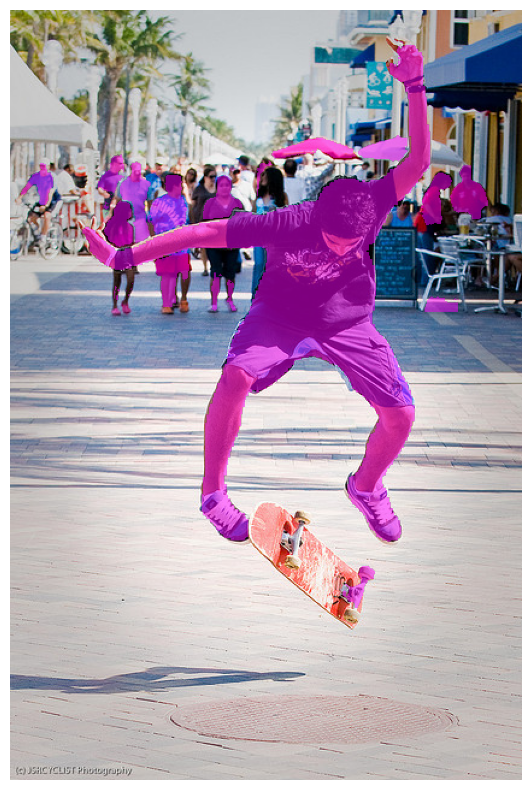

In [45]:
# 4. Visualisation finale
plt.figure(figsize=(10, 10))
plt.imshow(image)
masked_img = np.ma.masked_where(final_mask == 0, final_mask)
plt.imshow(masked_img, cmap='spring', alpha=0.5)
plt.axis('off')
plt.show()

# Documentation du Projet : Pipeline de Segmentation d'Objets

Ce projet implémente un flux de travail complet pour détecter et segmenter des objets spécifiques au sein d'une image en combinant deux architectures de Deep Learning complémentaires.

## Comment faire fonctionner le projet

Pour exécuter ce pipeline dans Google Colab, suivez ces étapes dans l'ordre :

1.  **Installation & Imports** : Exécutez la première cellule pour importer les bibliothèques (`transformers`, `torch`, etc.). Si les bibliothèques manquent, décommentez et lancez la commande `pip install`.
2.  **Chargement de l'image** : La cellule 1 télécharge une image depuis MS COCO. Vous pouvez modifier la variable `url` pour tester une autre image.
3.  **Détection** : Lancez la cellule 2 pour que le modèle **YOLOS** identifie les objets. Les résultats s'affichent sous forme de texte (nombre d'objets).
4.  **Segmentation localisée** : Exécutez la cellule 3. Pour chaque objet, vous verrez apparaître le "crop" (l'image découpée) et son masque de segmentation correspondant.
5.  **Rendu final** : La dernière cellule de code affiche l'image originale avec tous les masques superposés en couleur.

## Architecture du Pipeline

### 1. Acquisition de Données
Utilisation d'images provenant du dataset **MS COCO**.

### 2. Détection d'Objets (YOLOS)
- **Rôle** : Identifier les boîtes englobantes et les classes.
- **Modèle** : `hustvl/yolos-small`.

### 3. Segmentation par Instance Localisée (MaskFormer)
- **Crop & Segment** : Chaque objet détecté est extrait. Le modèle `MaskFormer` génère un masque binaire pour l'objet principal dans ce recadrage.
- **Affichage Intermédiaire** : Le code affiche désormais côte à côte l'objet extrait et son masque de segmentation.
- **Reprojection** : Les masques sont ensuite fusionnés sur un canevas global.

### 4. Synthèse Finale
Superposition du masque global sur l'image source pour une vue d'ensemble des segmentations.

## Bibliothèques
`Transformers`, `PyTorch`, `Pillow`, `Matplotlib`, `NumPy`.